In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import os

for root, dirs, files in os.walk("../data"):
    print(root)
    print(files)
    print("-"*40)

../data
['raw']
----------------------------------------


In [1]:
import os
os.listdir("../data")

['raw']

In [2]:
import pandas as pd

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
news = pd.read_csv("../data/raw/newsData/raw_analyst_ratings.csv")
news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

stock = pd.read_csv("../data/raw/yfinance_data/data/AAPL.csv")

stock.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
stock = pd.read_csv("../data/raw/yfinance_data/data/AAPL.csv")

In [7]:
news = pd.read_csv("../data/raw/newsData/raw_analyst_ratings.csv")

In [8]:
stock['Date'] = pd.to_datetime(stock['Date'])
stock = stock.sort_values('Date')

stock['returns'] = stock['Close'].pct_change() * 100

In [9]:
stock = pd.read_csv("../data/raw/yfinance_data/data/AAPL.csv")
stock.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stock['Date'] = pd.to_datetime(stock['Date'])
stock = stock.sort_values('Date')

stock['returns'] = stock['Close'].pct_change() * 100

stock[['Date', 'Close', 'returns']].head()

,Date,Close,returns
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959


In [11]:
news['date'] = pd.to_datetime(news['date'], errors='coerce')
news['date_only'] = news['date'].dt.date
stock['date_only'] = stock['Date'].dt.date

In [15]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...


True

In [ ]:
news['date'] = pd.to_datetime(news['date'], errors='coerce')
news['date_only'] = news['date'].dt.date
stock['date_only'] = stock['Date'].dt.date

In [20]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

news['sentiment'] = news['headline'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)

news[['headline', 'sentiment']].head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,headline,sentiment
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


In [21]:
print(news.columns)

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock',
       'date_only', 'sentiment'],
      dtype='str')


In [22]:
news['date'] = pd.to_datetime(news['date'], errors='coerce')
news['date_only'] = news['date'].dt.date

In [23]:
daily_sentiment = news.groupby('date_only', as_index=False)['sentiment'].mean()

daily_sentiment.head()

,date_only,sentiment
0,2011-04-27,0.00000
1,2011-04-28,0.12500
2,2011-04-29,0.36755
3,2011-04-30,0.20230
4,2011-05-01,0.00000


In [25]:
daily_sentiment = news.groupby('date_only', as_index=False)['sentiment'].mean()

In [26]:
daily_sentiment = news.groupby('date_only', as_index=False)['sentiment'].mean()

daily_sentiment.head()

,date_only,sentiment
0,2011-04-27,0.00000
1,2011-04-28,0.12500
2,2011-04-29,0.36755
3,2011-04-30,0.20230
4,2011-05-01,0.00000


In [27]:
merged = pd.merge(stock, daily_sentiment, on='date_only', how='inner')

In [28]:
merged['sentiment'].corr(merged['returns'])

np.float64(0.04525717478309481)

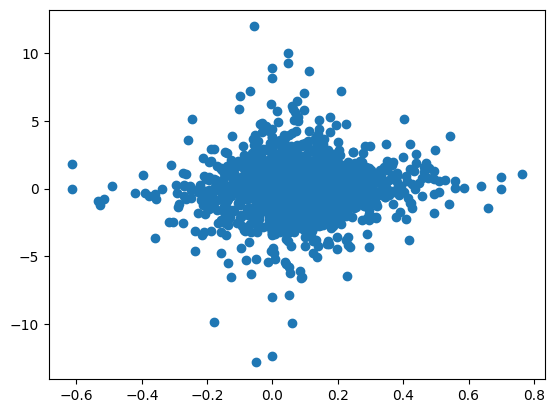

In [29]:
plt.scatter(merged['sentiment'], merged['returns'])

In [30]:
merged = pd.merge(stock, daily_sentiment, on='date_only', how='inner')

merged[['Date', 'Close', 'returns', 'sentiment']].head()

,Date,Close,returns,sentiment
0,2011-04-27,10.501366,-0.077042,0.000000
1,2011-04-28,10.399394,-0.971032,0.125000
2,2011-04-29,10.500770,0.974822,0.367550
3,2011-05-02,10.385298,-1.099651,0.136444
4,2011-05-03,10.442881,0.554465,0.000000


In [31]:
correlation = merged['sentiment'].corr(merged['returns'])
correlation

np.float64(0.04525717478309481)

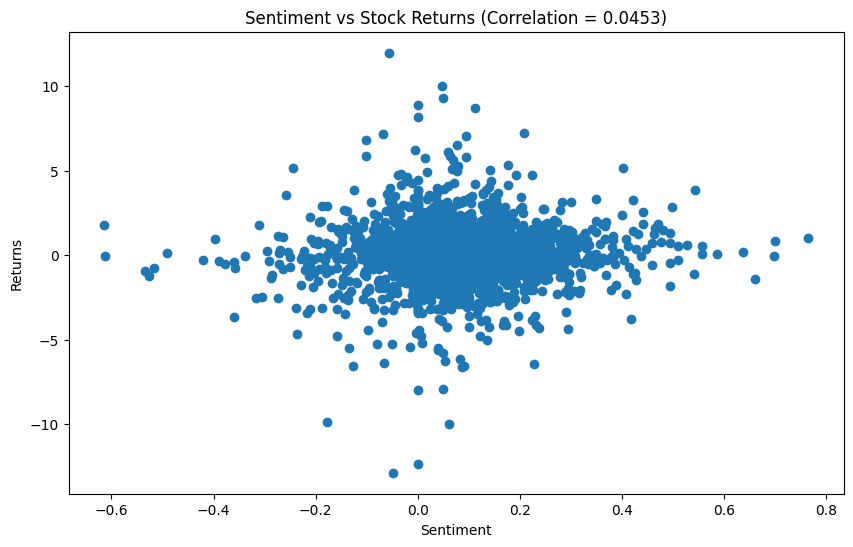

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(merged['sentiment'], merged['returns'])
plt.title(f"Sentiment vs Stock Returns (Correlation = {correlation:.4f})")
plt.xlabel("Sentiment")
plt.ylabel("Returns")
plt.show()

In [2]:
import pandas as pd
import numpy as np

stock = pd.read_csv("../data/raw/yfinance_data/data/AAPL.csv")
news = pd.read_csv("../data/raw/newsData/raw_analyst_ratings.csv")

In [3]:
stock['Date'] = pd.to_datetime(stock['Date'])
stock = stock.sort_values('Date')

stock['returns'] = stock['Close'].pct_change() * 100

stock['date_only'] = stock['Date'].dt.date

In [4]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

news['sentiment'] = news['headline'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)

news['date'] = pd.to_datetime(news['date'], errors='coerce')
news['date_only'] = news['date'].dt.date

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [5]:
daily_sentiment = news.groupby('date_only')['sentiment'].mean().reset_index()

merged = pd.merge(stock, daily_sentiment, on='date_only', how='inner')

merged.head()

,Date,Close,High,Low,Open,Volume,returns,date_only,sentiment
0,2011-04-27,10.501366,10.567347,10.409894,10.564047,356213200,-0.077042,2011-04-27,0.000000
1,2011-04-28,10.399394,10.489366,10.362505,10.382599,360959200,-0.971032,2011-04-28,0.125000
2,2011-04-29,10.500770,10.615335,10.397000,10.400299,1006345200,0.974822,2011-04-29,0.367550
3,2011-05-02,10.385298,10.510960,10.361905,10.489067,442713600,-1.099651,2011-05-02,0.136444
4,2011-05-03,10.442881,10.493565,10.365504,10.436583,313348000,0.554465,2011-05-03,0.000000


In [6]:
merged['target'] = (merged['returns'] > 0).astype(int)

In [7]:
merged['target'] = (merged['returns'] > 0).astype(int)

merged[['returns', 'target']].head()

,returns,target
0,-0.077042,0
1,-0.971032,0
2,0.974822,1
3,-1.099651,0
4,0.554465,1


In [8]:
X = merged[['sentiment']]
y = merged['target']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
accuracy = model.score(X_test, y_test)
accuracy

0.5269058295964125

In [12]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 1, 1, 0, 1, 1, 1, 1, 1])

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 28 191]
 [ 20 207]]
              precision    recall  f1-score   support

           0       0.58      0.13      0.21       219
           1       0.52      0.91      0.66       227

    accuracy                           0.53       446
   macro avg       0.55      0.52      0.44       446
weighted avg       0.55      0.53      0.44       446



In [14]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 28 191]
 [ 20 207]]
              precision    recall  f1-score   support

           0       0.58      0.13      0.21       219
           1       0.52      0.91      0.66       227

    accuracy                           0.53       446
   macro avg       0.55      0.52      0.44       446
weighted avg       0.55      0.53      0.44       446

